## MARKET BASKET ANALYSIS

In [1]:
# Install library (run only once)
#!pip install mlxtend  --ML Extensions for Data Science and Machine Learning
#!pip install numpy==1.26.4
#!pip install jupytext --To sync Jupyter notebooks with Python script files
#!jupytext --set-formats ipynb,py market_basket_analysis.ipynb -- To convert Jupyter notebook to Python script and vice versa

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical computations
import numpy as np

# Import matplotlib for visualizations
import matplotlib.pyplot as plt

# Import plotly for interactive visualizations
import plotly.express as px

# Import Apriori algorithm and association rules
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
df_main = pd.read_csv("E:/Market Basket Analysis/data/Online_Retail.csv", encoding='cp1252')
df = df_main

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 66.2 MB


In [5]:
# Data Preprocessing

# Remove rows with missing product descriptions
df.dropna(subset=['Description'], inplace=True)

# Remove cancelled invoices
df = df[~df['InvoiceNo'].str.startswith('C')]

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# Remove negative or zero unit prices
df = df[df['UnitPrice'] > 0]

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Standardize product descriptions
df['Description'] = df['Description'].str.strip().str.upper()

In [ ]:
#Further Data Cleaning
unique_products = pd.Series(df['Description'].unique())
unique_products.head(10)

# Save unique products to a CSV file
#unique_products.to_csv("E:/Market Basket Analysis/data/unique_products.csv", index=False)

In [12]:
# List of non-product / operational entries
exclude_items = [
    'POSTAGE',
    'DOTCOM POSTAGE',
    'BANK CHARGES',
    'PACKING CHARGE',
    'MANUAL',
    'DOTCOMGIFTSHOP GIFT VOUCHER £10.00',
    'DOTCOMGIFTSHOP GIFT VOUCHER £20.00',
    'DOTCOMGIFTSHOP GIFT VOUCHER £50.00'
]

# Remove rows where Description is in exclude_items list
df = df[~df['Description'].isin(exclude_items)]

In [13]:
#Feature engineering

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,Hour,Weekday,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,Wednesday,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,Wednesday,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34


In [14]:
# Export cleaned dataset to CSV & Excel


df.to_csv("E:/Market Basket Analysis/outputs/Online_Retail_Cleaned.csv", index=False)
df.to_excel("E:/Market Basket Analysis/outputs/Online_Retail_Cleaned.xlsx", index=False)

#Print success messages
print("CSV & Excel files are exported successfully!")

CSV & Excel files are exported successfully!



## GLOBAL OVERVIEW ANALYSIS



In [15]:
# Global KPIs
total_revenue = df['Revenue'].sum()
total_transactions = df['InvoiceNo'].nunique()  
total_items_sold = df['Quantity'].sum()
unique_customers = df['CustomerID'].nunique()
unique_products = df['Description'].nunique()
unique_countries = df['Country'].nunique()
print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions}")
print(f"Total Items Sold: {total_items_sold}")
print(f"Unique Customers: {unique_customers}")
print(f"Unique Products: {unique_products}")
print(f"Unique Countries: {unique_countries}")  


Total Revenue: £10,279,327.75
Total Transactions: 19781
Total Items Sold: 5561530
Unique Customers: 4334
Unique Products: 4007
Unique Countries: 38


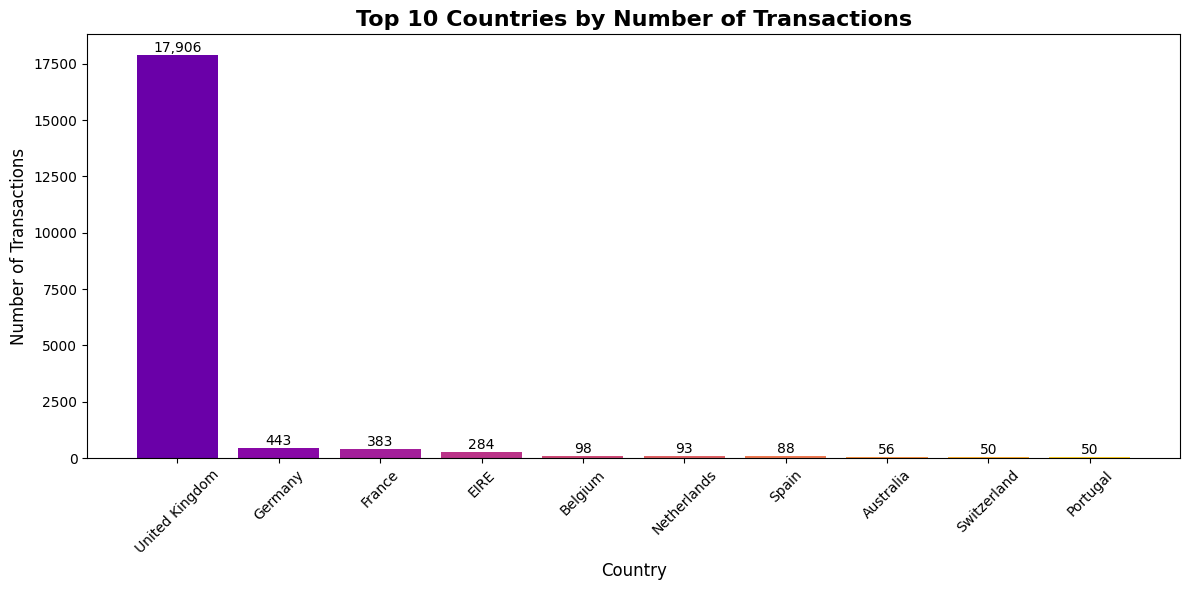

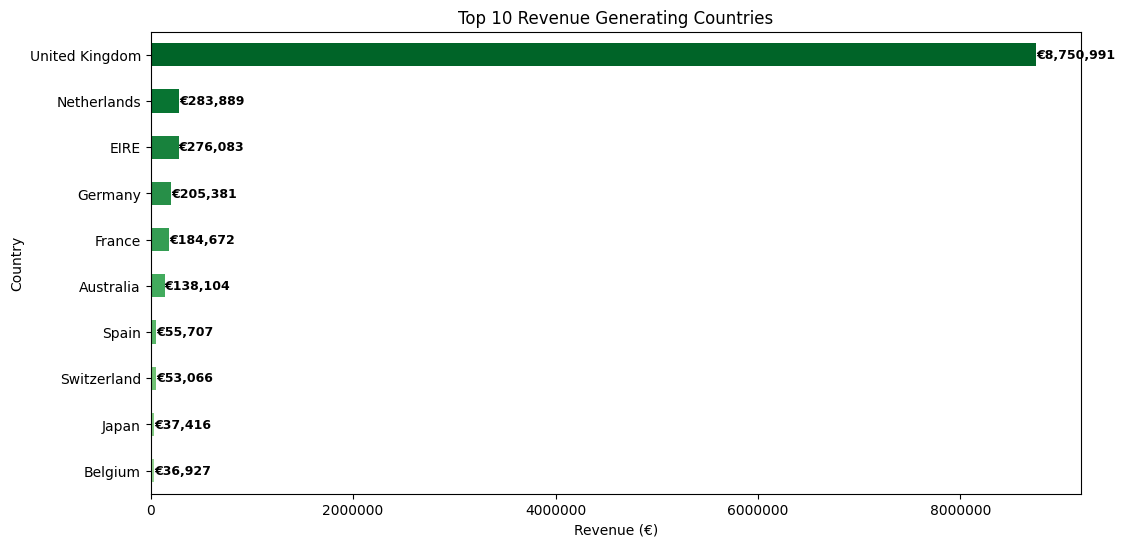

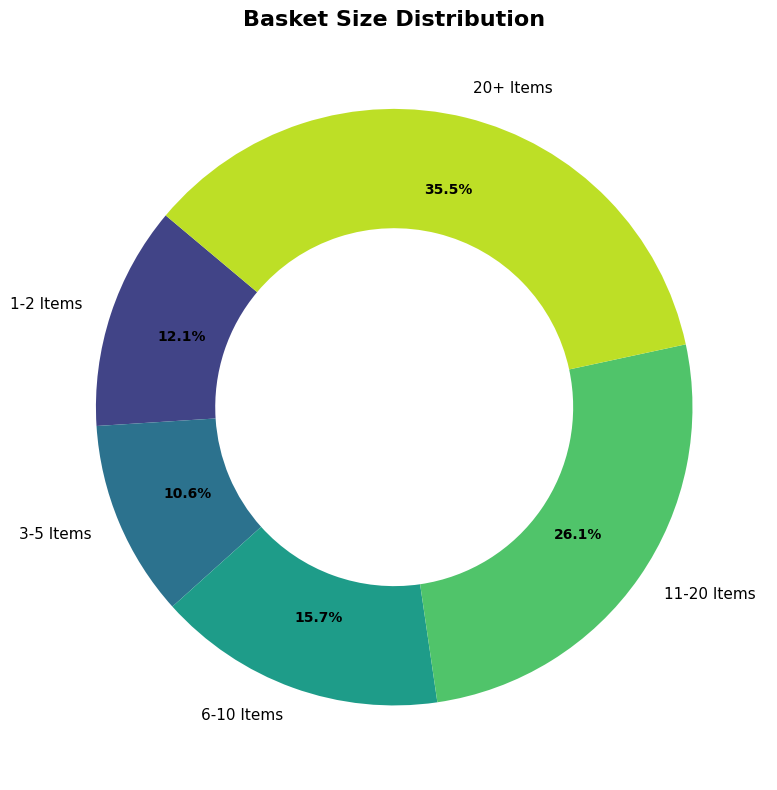

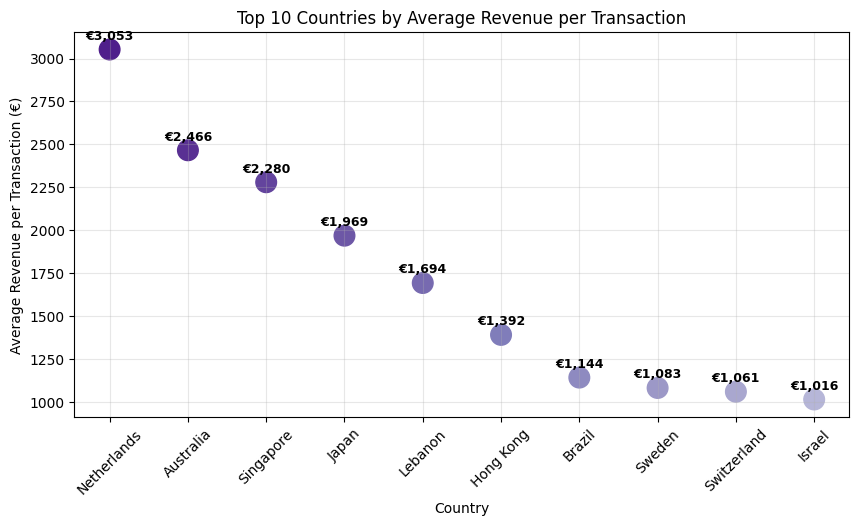

In [16]:
# ==========================================
# 1. Top 10 Countries by Number of Transactions
# HORIZONTAL BAR CHART
# =========================================
top_transactions_country = (
    df.groupby('Country')['InvoiceNo']
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

# Gradient Colors
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(top_transactions_country)))

bars = plt.bar(
    top_transactions_country.index,
    top_transactions_country.values,
    color=colors
)

# Title and Labels
plt.title('Top 10 Countries by Number of Transactions',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Rotate country names
plt.xticks(rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ==========================================
# 2. TOP 10 REVENUE GENERATING COUNTRIES
# HORIZONTAL BAR CHART
# ==========================================

top_revenue_countries = (
    df.groupby('Country')['Revenue']
           .sum()
           .sort_values(ascending=False)
           .head(10)
)

plt.figure(figsize=(12,6))

# Create green gradient colors
colors = plt.cm.Greens(
    np.linspace(0.4, 0.9, 10)
)

# Plot chart
ax = top_revenue_countries.sort_values().plot(
    kind='barh',
    color=colors
)

plt.title('Top 10 Revenue Generating Countries')

plt.xlabel('Revenue (€)')
plt.ylabel('Country')

plt.ticklabel_format(style='plain', axis='x')

# Add labels
for i in ax.patches:

    value = i.get_width()

    ax.annotate(
        f'€{value:,.0f}',
        (
            value,
            i.get_y() + i.get_height()/2
        ),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.show()

# ==========================================
# 3. BASKET SIZE DISTRIBUTION
# DONUT CHART
# ==========================================

# Basket Size = Number of unique products per transaction
basket_size = (
    df.groupby('InvoiceNo')['StockCode']
      .nunique()
)

# Basket Categories
basket_categories = pd.cut(
    basket_size,
    bins=[0, 2, 5, 10, 20, 100],
    labels=['1-2 Items', '3-5 Items', '6-10 Items',
            '11-20 Items', '20+ Items']
)

basket_distribution = basket_categories.value_counts().sort_index()

plt.figure(figsize=(10,8))

# Gradient Colors
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(basket_distribution)))

# Donut Chart
wedges, texts, autotexts = plt.pie(
    basket_distribution.values,
    labels=basket_distribution.index,      # Labels outside
    autopct='%1.1f%%',                     # Percentages inside
    startangle=140,
    colors=colors,
    pctdistance=0.75,                      # Move % inside donut
    labeldistance=1.1,                     # Move labels outside
    wedgeprops=dict(width=0.4),
    textprops=dict(fontsize=11)
)

# Style percentage text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

# Title
plt.title('Basket Size Distribution',
          fontsize=16,
          fontweight='bold')

plt.tight_layout()
plt.show()


# ==========================================
# 4. AVERAGE REVENUE PER TRANSACTION
# SCATTER PLOT
# ==========================================

revenue_per_transaction = (
    df.groupby('Country')
           .apply(
               lambda x:
               x['Revenue'].sum() /
               x['InvoiceNo'].nunique()
           )
           .sort_values(ascending=False)
           .head(10)
)

plt.figure(figsize=(10,5))

# Violet-Purple Gradient
colors = plt.cm.Purples(
    np.linspace(0.9, 0.4, 10)
)

plt.scatter(
    revenue_per_transaction.index,
    revenue_per_transaction.values,
    s=220,
    c=colors
)

plt.title('Top 10 Countries by Average Revenue per Transaction')

plt.xlabel('Country')
plt.ylabel('Average Revenue per Transaction (€)')

plt.xticks(rotation=45)

# Add labels
for x, y in zip(
    revenue_per_transaction.index,
    revenue_per_transaction.values
):

    plt.text(
        x,
        y + 40,
        f'€{y:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

plt.grid(alpha=0.3)

plt.show()

## Global Market Insights

The United Kingdom overwhelmingly dominated the dataset in total revenue and transaction volume, indicating a significantly richer customer activity base compared to other countries.
Although several countries exhibited larger average basket sizes and higher revenue per transaction, their overall transaction volumes were relatively small.
Therefore, the United Kingdom was selected for deeper Market Basket Analysis to generate more reliable and scalable customer purchasing insights. 

## United Kingdom Analysis

In [17]:
# Filter only United Kingdom data
df = df[df['Country'] == 'United Kingdom']

# Exporting UK data to Excel and CSV for further analysis
df.to_excel("E:/Market Basket Analysis/outputs/uk_data.xlsx", index=False)
df.to_csv("E:/Market Basket Analysis/outputs/uk_data.csv", index=False)

In [18]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Day,Hour,Weekday,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,1,8,Wednesday,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,1,8,Wednesday,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,1,8,Wednesday,20.34


In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 478907 entries, 0 to 541893
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    478907 non-null  str           
 1   StockCode    478907 non-null  str           
 2   Description  478907 non-null  str           
 3   Quantity     478907 non-null  int64         
 4   InvoiceDate  478907 non-null  datetime64[us]
 5   UnitPrice    478907 non-null  float64       
 6   CustomerID   348893 non-null  float64       
 7   Country      478907 non-null  str           
 8   Year         478907 non-null  int32         
 9   Month        478907 non-null  int32         
 10  Day          478907 non-null  int32         
 11  Hour         478907 non-null  int32         
 12  Weekday      478907 non-null  str           
 13  Revenue      478907 non-null  float64       
dtypes: datetime64[us](1), float64(3), int32(4), int64(1), str(5)
memory usage: 74.6 MB


In [ ]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     130014
Country             0
Year                0
Month               0
Day                 0
Hour                0
Weekday             0
Revenue             0
dtype: int64

In [21]:
# UK KPIs
total_revenue = df['Revenue'].sum()
total_transactions = df['InvoiceNo'].nunique()  
average_order_value = total_revenue / total_transactions
total_items_sold = df['Quantity'].sum()
average_basket_size = df.groupby('InvoiceNo')['Description'].nunique().mean()

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions}")
print(f"Average Order Value: £{average_order_value:,.2f}")
print(f"Total Items Sold: {total_items_sold}")
print(f"Average Basket Size: {average_basket_size:.2f}")
 


Total Revenue: £8,750,991.10
Total Transactions: 17906
Average Order Value: £488.72
Total Items Sold: 4639147
Average Basket Size: 26.44


## Hourly Transaction Trend - United Kingdom

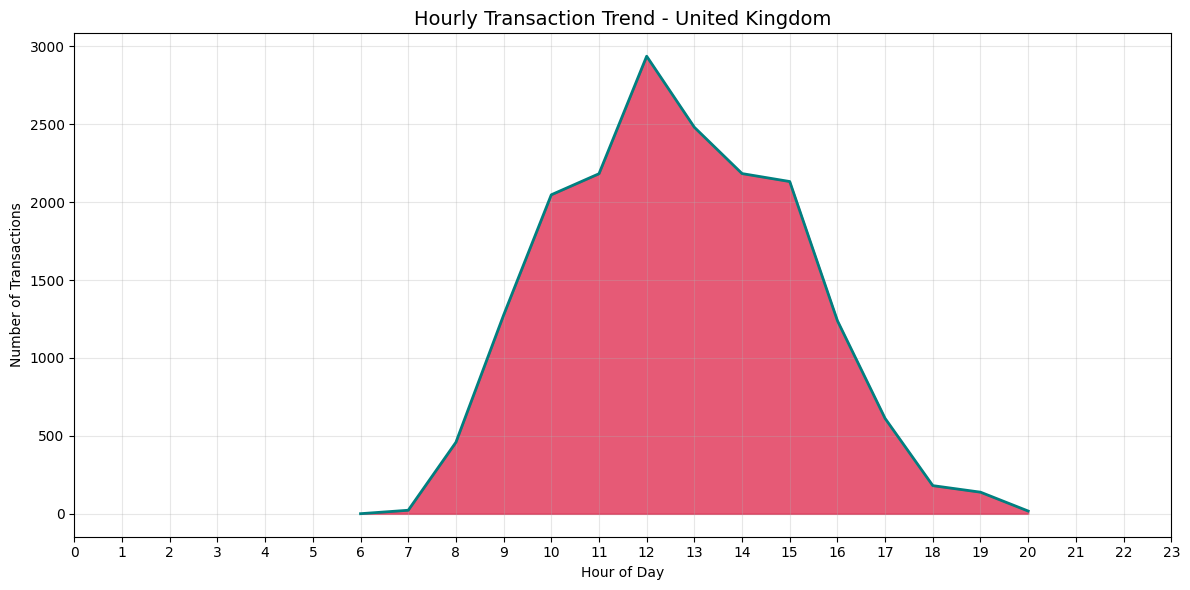

In [22]:
hourly_transactions = (df.groupby('Hour')['InvoiceNo']
         .nunique()
)

plt.figure(figsize=(12,6))

plt.fill_between(
    hourly_transactions.index,
    hourly_transactions.values,
    alpha=0.7,
    color = 'crimson'
)

plt.plot(
    hourly_transactions.index,
    hourly_transactions.values,
    linewidth=2,
    color = 'teal'
)

plt.title('Hourly Transaction Trend - United Kingdom', fontsize=14)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')

plt.xticks(range(0,24))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Monthly Demand Trend - United Kingdom

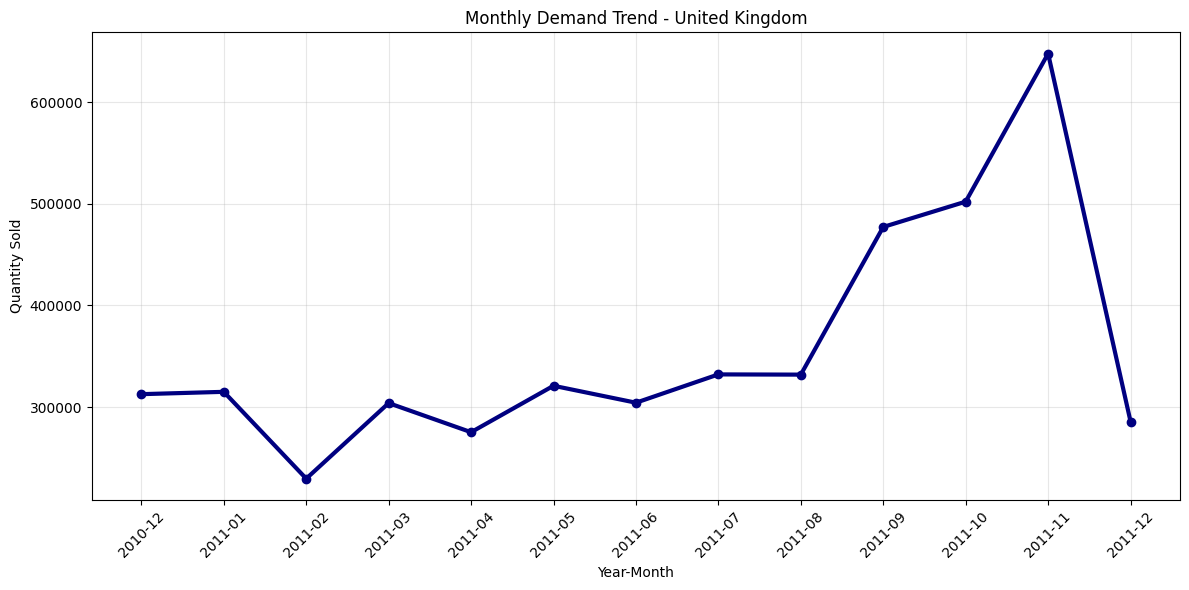

In [23]:
# Create Year-Month column
df['YearMonth'] = (
    df['Year'].astype(str)
    + '-'
    + df['Month'].astype(str).str.zfill(2)
)

# Monthly demand trend
monthly_demand = (
    df.groupby('YearMonth')['Quantity']
      .sum()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker='o',
    linewidth=3,
    color = 'navy'
)

plt.title('Monthly Demand Trend - United Kingdom')

plt.xlabel('Year-Month')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Top 10 Selling Products by Quantity - United Kingdom

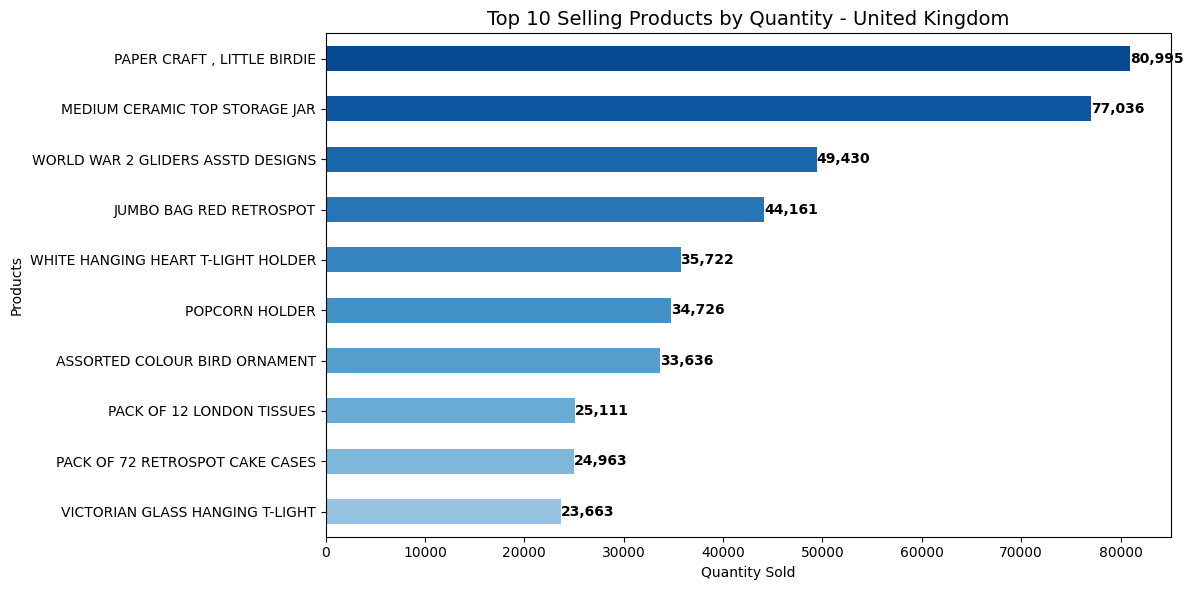

In [24]:
#Top 10 Selling Products by Quantity - United Kingdom
top_selling_products = (df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))

ax = top_selling_products.sort_values().plot(
    kind='barh',
    color=colors
)

plt.title('Top 10 Selling Products by Quantity - United Kingdom', fontsize=14)

plt.xlabel('Quantity Sold')
plt.ylabel('Products')

# Quantity labels
for i in ax.patches:

    value = i.get_width()

    ax.annotate(
        f'{int(value):,}',
        (
            value,
            i.get_y() + i.get_height()/2
        ),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()

plt.show()

## Top Revenue Generating Products - United Kingdom

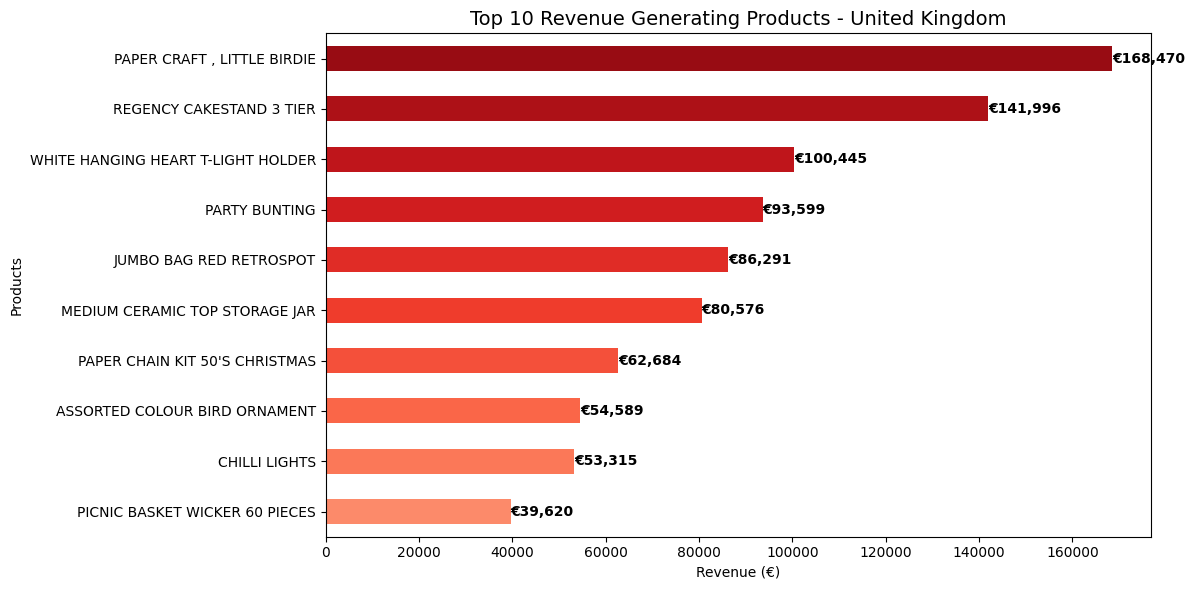

In [25]:
# Top Revenue Generating Products in UK

top_revenue_products = (df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12,6))

colors = plt.cm.Reds(np.linspace(0.4, 0.9, 10))

ax = top_revenue_products.sort_values().plot(
    kind='barh',
    color=colors
)

plt.title('Top 10 Revenue Generating Products - United Kingdom', fontsize=14)

plt.xlabel('Revenue (€)')
plt.ylabel('Products')

# Revenue labels
for i in ax.patches:

    value = i.get_width()

    ax.annotate(
        f'€{value:,.0f}',
        (
            value,
            i.get_y() + i.get_height()/2
        ),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()

plt.show()

## Basket Size Distribution - United Kingdom

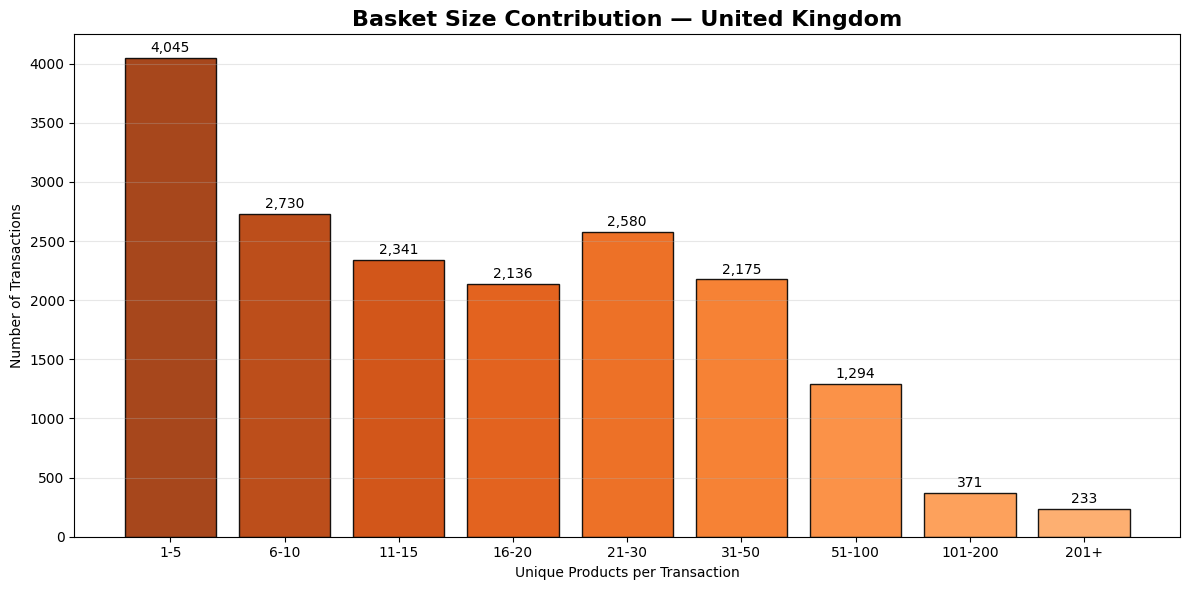

In [26]:
# Calculate basket size per transaction
basket_size = (
    df.groupby('InvoiceNo')['Description']
      .nunique()
)

# Create custom business-friendly bins
bins = [1, 5, 10, 15, 20, 30, 50, 100, 200, 1000]

# Labels for display
labels = [
    '1-5', '6-10', '11-15', '16-20',
    '21-30', '31-50', '51-100',
    '101-200', '201+'
]

# Categorize basket sizes
basket_categories = pd.cut(
    basket_size,
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count transactions in each category
basket_distribution = (
    basket_categories
    .value_counts()
    .sort_index()
)

# Plot
plt.figure(figsize=(12,6))

# Create orange gradient colors
colors = plt.cm.Oranges(
    np.linspace(0.9, 0.4, len(basket_distribution))
)

# Plot bars with gradient
bars = plt.bar(
    basket_distribution.index.astype(str),
    basket_distribution.values,
    color=colors,
    edgecolor='black',
    alpha=0.9
)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 50,
        f'{int(height):,}',
        ha='center',
        fontsize=10
    )

# Titles and labels
plt.title(
    'Basket Size Contribution — United Kingdom',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Unique Products per Transaction')
plt.ylabel('Number of Transactions')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## APRIORI ALGORITHM

In [27]:
# Create basket matrix
basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity'].sum().unstack().fillna(0))

In [28]:
# Convert quantities into 1 and 0
basket = (basket > 0).astype(int)

# Display basket matrix shape
print("Basket Matrix Shape:", basket.shape)

# Preview basket matrix
basket.head()

Basket Matrix Shape: (17906, 3988)


Description,*BOOMBOX IPOD CLASSIC,*USB OFFICE MIRROR BALL,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
# STEP 2: REMOVE RARE PRODUCTS
# Keep products purchased in at least 200 transactions
basket_filtered = basket.loc[:,basket.sum(axis=0) >= 200]

# Display new shape
print("Filtered Basket Shape:", basket_filtered.shape)

# Preview filtered basket
basket_filtered.head()

Filtered Basket Shape: (17906, 731)


Description,10 COLOUR SPACEBOY PEN,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE SKULLS,12 PENCILS TALL TUBE WOODLAND,15CM CHRISTMAS GLASS BALL 20 LIGHTS,3 HEARTS HANGING DECORATION RUSTIC,...,WOODEN UNION JACK BUNTING,WOODLAND CHARLOTTE BAG,WORLD WAR 2 GLIDERS ASSTD DESIGNS,WRAP ALPHABET DESIGN,WRAP ENGLISH ROSE,YOU'RE CONFUSING ME METAL SIGN,ZINC FOLKART SLEIGH BELLS,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
# support - how frequently an itemset appears in the dataset
# support(A) = (Number of transactions containing A) / (Total number of transactions)

# | Support Value        | Meaning                       |
# | -------------------- | ----------------------------- |
# | Very low (<0.01)     | Rare combination              |
# | Medium (0.01–0.05)   | Moderate occurrence           |
# | High (>0.05)         | Frequently purchased together |


# Confidence - how often item B is purchased in transactions that contain A
# confidence(A => B) = support(A U B) / support(A) 
#Confidence is directional so denominator is always support(A) 

# | Confidence Value   | Meaning                            |
# | ------------------ | ---------------------------------- |
# | Low (<0.3)         | Weak recommendation                |
# | Medium (0.3–0.7)   | Moderate predictive power          |
# | High (>0.7)        | Strong recommendation relationship |
  
# lift - how much more likely A and B are purchased together than if they were independent
# lift(A => B) = confidence(A => B) / support(B) 
# | Lift Value | Meaning                             |
# | ---------- | ----------------------------------- |
# | <1         | Negative/weak association           |
# | =1         | Independent products                |
# | >1         | Positive association                |
# | >3         | Strong association                  |
# | >10        | Extremely strong niche relationship |




In [31]:
# STEP 3: APPLY APRIORI ALGORITHM
# Generate frequent itemsets
frequent_itemsets = apriori(
    basket_filtered.astype(bool),
    min_support=0.005,
    use_colnames=True,
    low_memory=True,
    max_len=4
)

# Add itemset length
frequent_itemsets['Length'] = (
    frequent_itemsets['itemsets']
    .apply(len)
)

# Sort by support
frequent_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

print("\nFrequent Itemsets Summary:")
print(frequent_itemsets['Length'].value_counts().sort_index())

frequent_itemsets.head(10)


Frequent Itemsets Summary:
Length
1     731
2    8985
3    6173
4    2353
Name: count, dtype: int64


,support,itemsets,Length
699,0.120742,frozenset({WHITE HANGING HEART T-LIGHT HOLDER}),1
309,0.108064,frozenset({JUMBO BAG RED RETROSPOT}),1
501,0.094103,frozenset({REGENCY CAKESTAND 3 TIER}),1
416,0.088965,frozenset({PARTY BUNTING}),1
349,0.077739,frozenset({LUNCH BAG RED RETROSPOT}),1
43,0.076567,frozenset({ASSORTED COLOUR BIRD ORNAMENT}),1
565,0.069306,frozenset({SET OF 3 CAKE TINS PANTRY DESIGN}),1
375,0.068078,frozenset({NATURAL SLATE HEART CHALKBOARD}),1
341,0.067910,frozenset({LUNCH BAG BLACK SKULL.}),1
263,0.065006,frozenset({HEART OF WICKER SMALL}),1


## Association Rules

In [32]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

# Convert frozensets into readable strings
rules['antecedents'] = rules['antecedents'].apply(
    lambda x: ', '.join(list(x))
)

rules['consequents'] = rules['consequents'].apply(
    lambda x: ', '.join(list(x))
)

# Create rule length columns
rules['antecedent_len'] = rules['antecedents'].apply(
    lambda x: len(x.split(', '))
)

rules['consequent_len'] = rules['consequents'].apply(
    lambda x: len(x.split(', '))
)

# Filter strong business-relevant rules
strong_rules = rules[
    (rules['support'] >= 0.005) &
    (rules['confidence'] >= 0.5) &
    (rules['lift'] >= 5) &
    (rules['antecedent_len'] == 1) &
    (rules['consequent_len'] <= 3)
]

strong_rules = strong_rules.drop_duplicates()

# Sort by lift
strong_rules = strong_rules.sort_values(
    by=['lift','confidence'],
        ascending=False
)

# Round values
strong_rules = strong_rules.round(3)


strong_rules = strong_rules.rename(columns={
    'antecedents': 'Product Purchased',
    'consequents': 'Recommended Product'
})


# Reset index
strong_rules = strong_rules.reset_index(drop=True)
strong_rules.head(5)

,Product Purchased,Recommended Product,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedent_len,consequent_len
0,HERB MARKER CHIVES,"HERB MARKER MINT, HERB MARKER THYME, HERB MARK...",0.011,0.010,0.009,0.828,78.823,1.0,0.009,5.739,0.999,0.753,0.826,0.861,1,3
1,HERB MARKER CHIVES,"HERB MARKER MINT, HERB MARKER ROSEMARY, HERB M...",0.011,0.011,0.009,0.828,78.406,1.0,0.009,5.739,0.999,0.750,0.826,0.858,1,3
2,HERB MARKER CHIVES,"HERB MARKER ROSEMARY, HERB MARKER THYME, HERB ...",0.011,0.011,0.010,0.852,77.461,1.0,0.010,6.692,0.998,0.762,0.851,0.865,1,3
3,HERB MARKER CHIVES,"HERB MARKER BASIL, HERB MARKER THYME, HERB MAR...",0.011,0.010,0.009,0.808,77.358,1.0,0.009,5.151,0.998,0.726,0.806,0.842,1,3
4,HERB MARKER CHIVES,"HERB MARKER BASIL, HERB MARKER MINT, HERB MARK...",0.011,0.010,0.009,0.793,77.181,1.0,0.009,4.784,0.998,0.712,0.791,0.834,1,3


In [33]:
#Product Recommendation -- Keep only 1-to-1 rules for clear recommendations

Recommendations = strong_rules[
    (strong_rules['antecedent_len'] == 1) &
    (strong_rules['consequent_len'] == 1)
]

print(f"Total 1-to-1 Recommendations initially: {Recommendations.shape[0]}")

Total 1-to-1 Recommendations initially: 459


In [34]:
# Create pair key independent of direction

Recommendations['pair_key'] = Recommendations.apply(
    lambda row: tuple(sorted([row['Product Purchased'], row['Recommended Product']])),
    axis=1
)

# Keep highest confidence rule for each pair
Recommendations = (
    Recommendations
    .sort_values('confidence', ascending=False)
    .drop_duplicates(subset='pair_key')
)

# Optional cleanup
Recommendations = Recommendations.drop(columns='pair_key')

print(f"Primary Recommendations: {Recommendations.shape[0]}")

Recommendations=Recommendations[["Product Purchased", "Recommended Product", "support", "confidence", "lift"]]

# Keep only required columns and sort by lift
Recommendations.sort_values('lift', ascending=False).head(5)

Primary Recommendations: 368


,Product Purchased,Recommended Product,support,confidence,lift
70,HERB MARKER CHIVES,HERB MARKER PARSLEY,0.010,0.921,72.345
76,HERB MARKER THYME,HERB MARKER ROSEMARY,0.012,0.930,72.123
98,HERB MARKER PARSLEY,HERB MARKER THYME,0.012,0.908,70.682
102,HERB MARKER CHIVES,HERB MARKER THYME,0.010,0.906,70.566
107,HERB MARKER PARSLEY,HERB MARKER ROSEMARY,0.012,0.908,70.376


In [35]:
#Cross-Sell Recommendations - Keep only 1-to-2 rules for cross-selling opportunities
Cross_Sell = strong_rules[
    (strong_rules['antecedent_len'] == 1) &
    (strong_rules['consequent_len'] == 2)
]
Cross_Sell = Cross_Sell[["Product Purchased", "Recommended Product", "support", "confidence", "lift"]]

print(f"Cross-Sell Recommendations : {Cross_Sell.shape[0]}")
Cross_Sell.sort_values('lift', ascending=False).head(5)

Cross-Sell Recommendations : 99


,Product Purchased,Recommended Product,support,confidence,lift
14,HERB MARKER CHIVES,"HERB MARKER MINT, HERB MARKER PARSLEY",0.01,0.872,76.159
17,HERB MARKER PARSLEY,"HERB MARKER CHIVES, HERB MARKER THYME",0.01,0.781,75.974
18,HERB MARKER PARSLEY,"HERB MARKER CHIVES, HERB MARKER ROSEMARY",0.01,0.776,75.960
19,HERB MARKER CHIVES,"HERB MARKER THYME, HERB MARKER PARSLEY",0.01,0.877,75.849
21,HERB MARKER PARSLEY,"HERB MARKER CHIVES, HERB MARKER MINT",0.01,0.776,75.547


In [36]:
#Bundle Strategies - Keep only 1-to-3 rules for potential bundle offers
Bundle_Offers = strong_rules[
    (strong_rules['antecedent_len'] == 1) &
    (strong_rules['consequent_len'] == 3)
]

Bundle_Offers = Bundle_Offers[["Product Purchased", "Recommended Product", "support", "confidence", "lift"]]

print(f"Bundle Recommendations : {Bundle_Offers.shape[0]}")
Bundle_Offers.sort_values('lift', ascending=False).head(5)

Bundle Recommendations : 64


,Product Purchased,Recommended Product,support,confidence,lift
0,HERB MARKER CHIVES,"HERB MARKER MINT, HERB MARKER THYME, HERB MARK...",0.009,0.828,78.823
1,HERB MARKER CHIVES,"HERB MARKER MINT, HERB MARKER ROSEMARY, HERB M...",0.009,0.828,78.406
2,HERB MARKER CHIVES,"HERB MARKER ROSEMARY, HERB MARKER THYME, HERB ...",0.010,0.852,77.461
3,HERB MARKER CHIVES,"HERB MARKER BASIL, HERB MARKER THYME, HERB MAR...",0.009,0.808,77.358
4,HERB MARKER CHIVES,"HERB MARKER BASIL, HERB MARKER MINT, HERB MARK...",0.009,0.793,77.181


In [37]:
# Print strong rules summary - Run only once to save to Excel when changed the above code.

Recommendations.to_excel("E:/Market Basket Analysis/outputs/Primary_Recommendations.xlsx", index=False)
Cross_Sell.to_excel("E:/Market Basket Analysis/outputs/Cross_Sell_Recommendations.xlsx", index=False)
Bundle_Offers.to_excel("E:/Market Basket Analysis/outputs/Bundle_Recommendations.xlsx", index=False)

#Print success messages
print("Primary Recommendations saved to Excel successfully!")   
print("Cross-Sell Recommendations saved to Excel successfully!")   
print("Bundle Recommendations saved to Excel successfully!")   

Primary Recommendations saved to Excel successfully!
Cross-Sell Recommendations saved to Excel successfully!
Bundle Recommendations saved to Excel successfully!
